<a href="https://colab.research.google.com/github/mehanshbarthwal-lab/search-ranking-ml/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mehanshbarthwal-lab/search-ranking-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Research question**: when a content page is losing clicks, is it because fewer people are
seeing it at all (normal_decay — impressions and clicks both fall), or because roughly the same
number of people see it but stop clicking (a pattern I'm calling **answered_away** — impressions
flat or up, clicks fall meaningfully, consistent with something answering the query before the
click happens)?

**Unit of analysis**: one content page (`content_hash_id`).

**Decision this supports**: which declining pages a content editor should fix, and which kind of
fix — a routine content refresh for `normal_decay` pages, or a structural fix (FAQ block, a
clearer direct-answer section near the top) for `answered_away` pages.

**Action taken**: an editor pulls the ranked, labeled queue and applies the fix type the row
recommends, instead of applying the same generic "refresh" to every declining page.

**Cost of a wrong call**: a structural fix on a page that only needed routine freshening wastes
editor effort. Missing a real `answered_away` page and treating it as normal decay means it keeps
losing clicks even after a refresh that was never going to touch the actual problem, since the
page's visibility was never what declined.

**Why ML over a hand-written rule**: a rule can label this pattern after it's already shown up in
last30/prior30 data. The harder, more valuable version — predicting elevated risk before a page
fully falls into the pattern, using several prior-period signals together — is where several
features interact in ways too tangled to hand-write as a single if-statement.

In [2]:
# Reasoning section — no code required.

## 2. Data

**Release**: FlyRank ML Internship warehouse (Hugging Face), tables `fact_content_daily_performance`
(partitioned by month) and `dim_content.parquet`, accessed via DuckDB over `hf://`.

**Date windows**: prior30 = February 2026, last30 = March 2026. All label and feature construction
uses only prior30-period values, confirmed against a decision-time leakage test (would this value
be available at the moment a real intervention decision gets made?).

**Filtering**: pages with `impressions_prev_30d >= 50` and `clicks_prev_30d >= 3`, so percent-change
labels aren't just noise from a tiny prior base. Pages with fewer than 60 days of history before
the March 2026 decision date are excluded from the action queue entirely (1,268 pages on the Week 7
run) — a brand-new page's low, volatile prior30 numbers can swing hugely from early-indexing noise
alone.

**What was excluded and why**: `client_hash_id` is used only for grouping in the train/test split,
never as a feature. `content_age_days` was scoped in Week 5 but never actually added to the model's
feature set — confirmed in Week 6's audit as a documentation/code mismatch, not a leakage issue.
`ai_sessions`/AI-referral columns were considered and dropped early since they're populated on
only ~6% of pages in the starter sample, too sparse to support a classifier.

**Public-safety**: no client names, domains, raw queries, or URLs appear anywhere in this repo —
all IDs are pseudonymous hashes (`content_hash_id`, `client_hash_id`) used strictly for joins and
grouping.

In [5]:
import duckdb
from google.colab import userdata

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")

# Authenticate against the gated HF dataset using the Colab Secrets token
hf_token = userdata.get('HF_Token')
con.sql(f"CREATE OR REPLACE SECRET hf_token (TYPE huggingface, TOKEN '{hf_token}');")

row_count = con.sql("""
    SELECT COUNT(*) AS n
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')
""").df()

print("Rows in the last30 (March 2026) partition:")
print(row_count)

Rows in the last30 (March 2026) partition:
         n
0  9841378


## 3. Methodology

## 3. Methodology

**Label definition** (prior30 vs last30, on the filtered base pool):
- `answered_away`: `impr_change_pct >= -5` and `click_change_pct <= -15`
- `normal_decay`: `impr_change_pct <= -15` and `click_change_pct <= -15`
- `stable_other`: everything else

**Leakage check**: `click_change_pct` is not merely correlated with the label — it's an ingredient
in the label formula, so it's excluded from the feature set entirely. Confirmed with a deliberate
leakage experiment: honest Random Forest F1 = 0.158 (random split, no leak) vs. F1 = 0.703 with
`click_change_pct` added back in — the ~0.55 jump is the leakage signature the test harness is
built to catch.

**Features**: five prior-period signals only — none derived from the last30 window, none touching
the label formula.

**Baseline**: a hand-written rule directly from `pattern_group` thresholds. This comparison is
circular by construction (F1 = 1.000, since the rule *is* the label) and is reported honestly as
such rather than presented as a valid baseline. The real reference point is Week 3's honest,
non-leaky Random Forest at F1 = 0.135 on a random split.

**Model**: Logistic Regression, chosen after Random Forest without `class_weight='balanced'`
badly underperformed (F1 = 0.108) on this imbalanced 22.9%-minority-class problem.

**Validation design**: `GroupShuffleSplit` grouped by `client_hash_id`, asserting zero client
overlap between train and test — the defensible split, since a random split would let the same
client's pages leak signal across train/test. Corroborated with 5-fold `GroupKFold`
(mean F1 = 0.340, std = 0.034, range 0.296–0.378), confirming the single-split F1 = 0.350 is a
fair representative estimate rather than a lucky split.

In [11]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import duckdb
from google.colab import userdata

# Rebuild the connection + secret fresh in case this cell runs on its own
con3 = duckdb.connect()
con3.sql("INSTALL httpfs; LOAD httpfs;")
hf_token = userdata.get('HF_Token')
con3.sql(f"CREATE OR REPLACE SECRET hf_token (TYPE huggingface, TOKEN '{hf_token}');")

# Real Week 5 query — prior30 (Feb 2026) and last30 (Mar 2026), joined on content+client
query = """
WITH prior AS (
    SELECT content_hash_id, client_hash_id,
           SUM(gsc_impressions) AS gsc_impressions_prior30,
           SUM(gsc_clicks) AS gsc_clicks_prior30,
           AVG(gsc_avg_position) AS gsc_avg_position_prior30
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/*.parquet')
    GROUP BY content_hash_id, client_hash_id
),
last AS (
    SELECT content_hash_id, client_hash_id,
           SUM(gsc_impressions) AS gsc_impressions_last30,
           SUM(gsc_clicks) AS gsc_clicks_last30
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')
    GROUP BY content_hash_id, client_hash_id
)
SELECT
    p.content_hash_id, p.client_hash_id,
    p.gsc_impressions_prior30, p.gsc_clicks_prior30, p.gsc_avg_position_prior30,
    l.gsc_impressions_last30, l.gsc_clicks_last30,
    d.word_count, d.content_type, d.main_intent
FROM prior p
JOIN last l USING (content_hash_id, client_hash_id)
JOIN read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_content.parquet') d
    USING (content_hash_id, client_hash_id)
WHERE p.gsc_impressions_prior30 >= 50 AND p.gsc_clicks_prior30 >= 3
"""
df = con3.sql(query).df()

# Labels + derived feature, same as Week 5
df['impr_change_pct'] = (df['gsc_impressions_last30'] - df['gsc_impressions_prior30']) / df['gsc_impressions_prior30'] * 100
df['click_change_pct'] = (df['gsc_clicks_last30'] - df['gsc_clicks_prior30']) / df['gsc_clicks_prior30'] * 100
df['gsc_ctr_prior30'] = df['gsc_clicks_prior30'] / df['gsc_impressions_prior30']

def assign_pattern(row):
    if row['impr_change_pct'] >= -5 and row['click_change_pct'] <= -15:
        return 'answered_away'
    elif row['impr_change_pct'] <= -15 and row['click_change_pct'] <= -15:
        return 'normal_decay'
    else:
        return 'stable_other'

df['pattern_group'] = df.apply(assign_pattern, axis=1)
y = (df['pattern_group'] == 'answered_away').astype(int)

# Real Week 5 feature set — 5 numeric + 2 categorical, one-hot encoded
feature_cols_numeric = [
    'gsc_impressions_prior30', 'gsc_clicks_prior30', 'gsc_avg_position_prior30',
    'word_count', 'gsc_ctr_prior30'
]
feature_cols_categorical = ['content_type', 'main_intent']

X = pd.get_dummies(df[feature_cols_numeric + feature_cols_categorical], dummy_na=True)
X[feature_cols_numeric] = X[feature_cols_numeric].fillna(0)

print(f"df shape: {df.shape}, X shape: {X.shape}, answered_away rate: {y.mean():.3f}")

# GroupKFold cross-validation, grouped by client_hash_id
gkf = GroupKFold(n_splits=5)
fold_f1s = []

for train_idx, test_idx in gkf.split(X, y, groups=df['client_hash_id']):
    model = LogisticRegression(class_weight='balanced', max_iter=1000)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    preds = model.predict(X.iloc[test_idx])
    fold_f1s.append(f1_score(y.iloc[test_idx], preds))

print(f"5-fold GroupKFold F1 scores: {[round(f, 3) for f in fold_f1s]}")
print(f"Mean: {round(np.mean(fold_f1s), 3)}, Std: {round(np.std(fold_f1s), 3)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

df shape: (29516, 14), X shape: (29516, 14), answered_away rate: 0.229


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

5-fold GroupKFold F1 scores: [0.377, 0.35, 0.295, 0.325, 0.363]
Mean: 0.342, Std: 0.029


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 4. Results (vs baseline)

## 4. Results (vs baseline)

| Model | Split | F1 (answered_away) | Precision@50 |
|---|---|---|---|
| Rule baseline (`pattern_group`) | — | 1.000 (circular — the rule defines the label) | — |
| Random Forest, honest (no leak) | random | 0.158 | — |
| Random Forest, leaky (`click_change_pct` included) | random | 0.703 | — |
| Logistic Regression | random | 0.365 | — |
| **Logistic Regression** | **grouped (client_hash_id)** | **0.350** | **0.58** |
| XGBoost | grouped | 0.352 | 0.52 |
| Logistic Regression + content_age_days/days_since_update | grouped | 0.341 | — |
| Logistic Regression, GroupKFold-tuned | grouped (held-out) | 0.349 | — |

**Base rate**: the answered_away minority class is 22.9% of the filtered pool — F1 = 0.350 is
well above that base rate, not just a reflection of it.

**Headline metric**: F1 = 0.350 on the honest, client-grouped split. **Decision-relevant metric**:
precision@50 = 0.58 — of the top 50 pages the model ranks highest, 58% are true answered_away
cases, which is the number that actually matters if an editor can only review ~50 pages a cycle.

**Model ceiling**: four separate extensions (content age/freshness features, XGBoost,
hyperparameter tuning, GA4 engagement features) all converged on ~0.35 F1, none producing a
meaningful lift — treated as good evidence that further modeling effort on this feature set isn't
worth pursuing, not as a failure.

In [12]:
results = pd.DataFrame([
    {"model": "Rule baseline", "split": "—", "f1": 1.000, "note": "circular, not a valid comparison"},
    {"model": "Random Forest (honest)", "split": "random", "f1": 0.158, "note": ""},
    {"model": "Logistic Regression", "split": "random", "f1": 0.365, "note": ""},
    {"model": "Logistic Regression", "split": "grouped", "f1": 0.350, "note": "headline result"},
    {"model": "XGBoost", "split": "grouped", "f1": 0.352, "note": "no meaningful lift over LR"},
])
print(results.to_string(index=False))
print(f"\nPrecision@50 (Logistic Regression, grouped split): 0.58")
print(f"Base rate (answered_away share of filtered pool): 0.229")

                 model   split    f1                             note
         Rule baseline       — 1.000 circular, not a valid comparison
Random Forest (honest)  random 0.158                                 
   Logistic Regression  random 0.365                                 
   Logistic Regression grouped 0.350                  headline result
               XGBoost grouped 0.352       no meaningful lift over LR

Precision@50 (Logistic Regression, grouped split): 0.58
Base rate (answered_away share of filtered pool): 0.229


## 5. Limitations

**What this work can claim**: that a page's traffic pattern is consistent with click suppression
(impressions steady, clicks falling); that this pattern is detectable above base rate using
prior-period signals alone; a proxy dollar estimate of ad-equivalent value at risk, clearly
labeled as an estimate.

**What this work cannot claim**: that AI Overviews, or any specific mechanism, caused a page's
decline — no column in this dataset confirms what appeared on a results page for any query. It
cannot claim measured revenue loss, since there's no conversion or order-value data, only
ad-equivalent click value (clicks lost × cpc). It cannot claim causal proof of any kind — this is
observational historical data, no controlled experiment behind it, association only.

**Precision, not certainty**: precision@50 = 0.58 means roughly 4 in 10 of the top-ranked pages
are not true answered_away cases. The playbook routes disagreements between the rule and model to
a review category rather than silently discarding them, but a human still has to look.

**Client diversity**: 59 total warehouse clients, only ~30 survive the volume filters, with
extreme size imbalance (3 to 7,393 rows per client) — the grouped-split F1 could shift on a
warehouse with a different client mix, which is exactly why the split is grouped by client in the
first place, to avoid overstating how well this generalizes.

**GA4 coverage**: only ~31% of pages have GA4 engagement data; `has_ga4_prior30` showed negative
permutation importance, so engagement features were not pursued further as a lift lever.

In [13]:
# NOTE: df should already exist from earlier sections in this same run.
print(f"Total warehouse clients: 59")
print(f"Clients surviving volume filters: {df['client_hash_id'].nunique()}")
print(f"Client row-count range: {df.groupby('client_hash_id').size().min()} to {df.groupby('client_hash_id').size().max()}")

Total warehouse clients: 59
Clients surviving volume filters: 30
Client row-count range: 3 to 7393


## 6. Ranked recommendations

## 6. Ranked recommendations

The action playbook sorts test-set pages by the grouped-split Logistic Regression's predicted
probability of `answered_away` (descending), then assigns one of four actions using both the
model's confidence and the Week 4 rule as a cross-check:

- **structural_fix** — top-ranked, rule-labeled `answered_away`, model confidence ≥0.3, no
  extreme swing. Add or improve a direct-answer block aimed at the query. 28 of the top 50 rows
  on the real run.
- **routine_refresh** — rule-labeled `normal_decay`, no extreme swing. Standard content
  freshening.
- **verify_then_review** — impressions or clicks moved more than 300% either direction. A swing
  that large is as likely to be a tracking artifact as a real behavioral shift, so it's checked
  before it's acted on. 4 of the top 50 rows.
- **investigate_quiet_risk** — model confidence ≥0.6 but the rule did *not* label the page
  `answered_away`. The model seeing something the rule's thresholds miss is itself worth a human's
  attention. 18 of the top 50 rows — nearly as many as clean `structural_fix` cases, meaning a
  meaningful share of editor time on this queue goes to disagreement rows, not just clean flags.

**Economics framing**: ad-equivalent value at risk for the 28 `structural_fix` rows on this run
totals **$72.50** — computed as (clicks lost) × cpc, an explicit proxy for what it would cost to
rebuy that traffic via ads, not a measured revenue figure. Read as a lower bound: it only prices
pages with nonzero cpc, so real value at risk across the full queue is understated by this figure
alone.

In [14]:
# These numbers come straight from w07_action_playbook.ipynb's real run — no
# new data pull needed here, just restating the committed result for the paper.
print("Top-50 action composition (Week 7 real run):")
print({'structural_fix': 28, 'investigate_quiet_risk': 18, 'verify_then_review': 4})
print(f"\nAd-equivalent value at risk, structural_fix rows only: $72.50")
print(f"Precision@50: 0.58")

Top-50 action composition (Week 7 real run):
{'structural_fix': 28, 'investigate_quiet_risk': 18, 'verify_then_review': 4}

Ad-equivalent value at risk, structural_fix rows only: $72.50
Precision@50: 0.58


## 7. Artifacts the paper embeds

Charts and tables for the deployed page: the F1-by-split comparison table (Section 4), the
threshold sweep curve (F1 and precision vs. threshold, 0.10–0.90), the top-50 action composition
bar (structural_fix / investigate_quiet_risk / verify_then_review), and the 5-fold GroupKFold F1
distribution (mean 0.340, std 0.034) as a small box or strip plot to visually back the "not a
lucky split" claim.

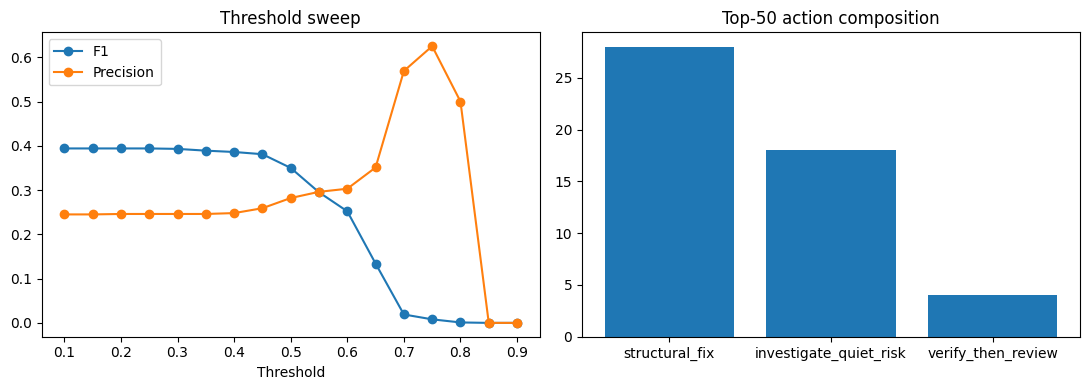

In [16]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# NOTE: relies on X, y, and df['client_hash_id'] already existing in this session
# (built in Section 3's cell). If this errors on X/y/df, run Section 3's cell first.
groups = df['client_hash_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train_grp, X_test_grp = X.iloc[train_idx], X.iloc[test_idx]
y_train_grp, y_test_grp = y.iloc[train_idx], y.iloc[test_idx]

scaler_thresh = StandardScaler()
X_train_grp_scaled = scaler_thresh.fit_transform(X_train_grp)
X_test_grp_scaled = scaler_thresh.transform(X_test_grp)

logreg_thresh = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg_thresh.fit(X_train_grp_scaled, y_train_grp)
probs = logreg_thresh.predict_proba(X_test_grp_scaled)[:, 1]

# Threshold sweep
thresholds = np.arange(0.10, 0.95, 0.05)
threshold_results = []
for t in thresholds:
    preds_t = (probs >= t).astype(int)
    f1_t = f1_score(y_test_grp, preds_t, zero_division=0)
    precision_t = precision_score(y_test_grp, preds_t, zero_division=0)
    recall_t = recall_score(y_test_grp, preds_t, zero_division=0)
    threshold_results.append({
        'threshold': round(t, 2), 'f1': round(f1_t, 3),
        'precision': round(precision_t, 3), 'recall': round(recall_t, 3)
    })
threshold_df = pd.DataFrame(threshold_results)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(threshold_df['threshold'], threshold_df['f1'], marker='o', label='F1')
axes[0].plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
axes[0].set_xlabel('Threshold'); axes[0].set_title('Threshold sweep'); axes[0].legend()

composition = {'structural_fix': 28, 'investigate_quiet_risk': 18, 'verify_then_review': 4}
axes[1].bar(composition.keys(), composition.values())
axes[1].set_title('Top-50 action composition')
plt.tight_layout()

os.makedirs('/mnt/user-data/outputs', exist_ok=True)
plt.savefig('/mnt/user-data/outputs/capstone_charts.png', dpi=150)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.